# Customer Churn Prediction — Modeling

## 1. Problem Definition

The objective is to build a machine learning classification model capable of predicting whether a customer will churn.

**Target:** `Churn`

- `1`: Customer churned
- `0`: Customer did not churn

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/raw/telco_churn.csv.txt")
#...nao deveriamos linkar com 01_EDA?

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Features and Target

The dataset is separated into predictor variables (`X`) and the target variable (`y`).

- **X:** customer characteristics used to make predictions.
- **y:** target variable (`Churn`) that the model will learn to predict.

In [5]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [6]:
X = X.drop(columns=["customerID"])

y = y.map({"No": 0, "Yes": 1})

## 3. Train-Test Split

The dataset is divided into training and test sets.

- **Training set:** used to train and optimize the models.
- **Test set:** kept unseen during model development and used only for final evaluation.

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
X_train.shape

(5634, 19)

In [10]:
X_test.shape

(1409, 19)

In [11]:
y_train.value_counts(normalize=True)

Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

In [12]:
y_test.value_counts(normalize=True)

Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64

## 4. Preprocessing

Data quality issues identified during exploratory data analysis are handled through reproducible preprocessing steps.

The original raw dataset is preserved unchanged. Transformations required for modeling are applied programmatically to ensure that the same processing can be reproduced on future data.

In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
numeric_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [17]:
categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]
categorical_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [19]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

                     X_train
                        │
            ┌───────────┴───────────┐
            ↓                       ↓
     numeric_features        categorical_features
            ↓                       ↓
    StandardScaler           OneHotEncoder
            │                       │
            └───────────┬───────────┘
                        ↓
                 dados preparados

## 5. Machine Learning Pipeline

A pipeline combines preprocessing and modeling into a single reproducible workflow.

This ensures that preprocessing steps are fitted only on the training data, reducing the risk of data leakage.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [21]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)
logistic_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Cross-Validation

Models are evaluated using stratified 5-fold cross-validation on the training set.

The test set remains untouched during model selection and hyperparameter optimization.

In [23]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [25]:
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [26]:
cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [27]:
cv_results

{'fit_time': array([0.1026938 , 0.05815434, 0.06733966, 0.05815792, 0.06788945]),
 'score_time': array([0.03445625, 0.03290486, 0.03648496, 0.03725624, 0.03949046]),
 'test_accuracy': array([0.7985803 , 0.78172138, 0.80301686, 0.81632653, 0.80994671]),
 'test_precision': array([0.64516129, 0.60728745, 0.65975104, 0.66428571, 0.68398268]),
 'test_recall': array([0.53511706, 0.50167224, 0.53177258, 0.62207358, 0.52842809]),
 'test_f1': array([0.58500914, 0.54945055, 0.58888889, 0.64248705, 0.59622642]),
 'test_roc_auc': array([0.84789071, 0.82512764, 0.84190054, 0.86287423, 0.852952  ])}

In [28]:
for metric in scoring:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(+/- {scores.std():.3f})"
    )

accuracy: 0.802 (+/- 0.012)
precision: 0.652 (+/- 0.026)
recall: 0.544 (+/- 0.041)
f1: 0.592 (+/- 0.030)
roc_auc: 0.846 (+/- 0.013)


### Logistic Regression — Cross-Validation Results

The Logistic Regression model achieved the following average performance across 5-fold cross-validation:

- **Accuracy: 80.2%** — The model correctly classified approximately 80% of customers overall.
- **Precision: 65.2%** — Among customers predicted to churn, approximately 65% actually churned.
- **Recall: 54.4%** — The model identified approximately 54% of all customers who actually churned, meaning that around 46% of churners were not detected.
- **F1-score: 59.2%** — The balance between precision and recall indicates moderate performance in identifying churners.
- **ROC-AUC: 84.6%** — The model shows good ability to distinguish customers with higher churn risk from those with lower churn risk.

The relatively high ROC-AUC suggests that the model ranks churn risk effectively. However, recall is considerably lower, indicating that the current classification threshold misses a substantial proportion of customers who eventually churn.

This Logistic Regression model will be used as a **baseline** for comparison with other machine learning algorithms. Model selection will be performed using cross-validation before evaluating the final selected model on the untouched test set.

## 7. Model Comparison

Multiple classification algorithms are evaluated using the same preprocessing pipeline and stratified 5-fold cross-validation.

The objective is to compare different modeling approaches under consistent conditions before performing hyperparameter optimization.

The initial models are:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Model performance is compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [31]:
results = []

In [32]:
for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

In [33]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Gradient Boosting,0.803340,0.662221,0.529097,0.587972,0.848228
0,Logistic Regression,0.801918,0.652094,0.543813,0.592412,0.846149
2,Random Forest,0.785413,0.627075,0.475585,0.540337,0.817969
1,Decision Tree,0.732161,0.495745,0.500334,0.497541,0.658235


### Model Comparison — Initial Results

The initial model comparison produced the following observations:

- **Gradient Boosting achieved the highest ROC-AUC (0.848) and Accuracy (80.3%)**, showing the strongest overall discrimination performance among the evaluated models.
- **Logistic Regression achieved a very similar ROC-AUC (0.846)** while obtaining the highest Recall (54.4%) and F1-score (59.2%).
- The difference in ROC-AUC between Gradient Boosting and Logistic Regression is small, suggesting that the additional model complexity does not yet provide a substantial performance improvement.
- **Random Forest underperformed both Logistic Regression and Gradient Boosting**, particularly in Recall.
- **Decision Tree showed the weakest overall performance**, with a ROC-AUC of approximately 0.658.

At this stage, Gradient Boosting and Logistic Regression are the strongest candidates. Further comparison with additional boosting algorithms and hyperparameter optimization is required before selecting the final model.

Because identifying customers at risk of churn is an important business objective, Recall will also be considered alongside ROC-AUC during model selection.

In [34]:
!pip install xgboost

In [35]:
import xgboost as xgb

In [36]:
from xgboost import XGBClassifier

In [37]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [38]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

In [39]:
xgb_scores = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


In [40]:
for metric in scoring:
    scores = xgb_scores[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(+/- {scores.std():.3f})"
    )

accuracy: 0.784 (+/- 0.012)
precision: 0.612 (+/- 0.031)
recall: 0.515 (+/- 0.024)
f1: 0.559 (+/- 0.022)
roc_auc: 0.825 (+/- 0.007)


In [41]:
!pip install lightgbm

In [43]:
import lightgbm as lgb

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", lgbm_model)
    ]
)

lgbm_scores = cross_validate(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    scores = lgbm_scores[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(+/- {scores.std():.3f})"
    )

accuracy: 0.797 (+/- 0.013)
precision: 0.646 (+/- 0.031)
recall: 0.520 (+/- 0.025)
f1: 0.576 (+/- 0.026)
roc_auc: 0.837 (+/- 0.008)


In [44]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

In [45]:
#models["Novo Modelo"] = NovoModelo()

In [46]:
results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

    results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Gradient Boosting,0.803340,0.662221,0.529097,0.587972,0.848228
0,Logistic Regression,0.801918,0.652094,0.543813,0.592412,0.846149
5,LightGBM,0.796950,0.646187,0.519732,0.575979,0.837331
4,XGBoost,0.784347,0.612095,0.515050,0.558985,0.824643
2,Random Forest,0.785413,0.627075,0.475585,0.540337,0.817969
1,Decision Tree,0.732161,0.495745,0.500334,0.497541,0.658235


In [47]:
results_df.to_csv(
    "results/baseline_model_comparison.csv",
    index=False
)

### Baseline Model Selection

Six classification algorithms were evaluated using identical preprocessing and stratified 5-fold cross-validation.

The strongest baseline models were:

- **Gradient Boosting**, with the highest ROC-AUC of approximately **0.848**.
- **Logistic Regression**, with a very similar ROC-AUC of approximately **0.846**, while achieving the highest Recall and F1-score.

More complex ensemble models did not automatically outperform the simpler Logistic Regression baseline. LightGBM achieved competitive performance, while the default configurations of XGBoost, Random Forest, and Decision Tree produced lower validation scores.

Based on these results, **Gradient Boosting and Logistic Regression are the primary candidates for further optimization**. Hyperparameter tuning will be performed using only the training data, while the test set remains untouched for final evaluation.

## 8. Hyperparameter Optimization

The strongest and most relevant baseline models are further optimized through hyperparameter tuning.

Randomized search combined with stratified cross-validation is used to explore different hyperparameter configurations without accessing the test set.

**Optimization metric:** ROC-AUC

Models selected for optimization:

- Logistic Regression
- Gradient Boosting
- XGBoost
- LightGBM

In [48]:
from sklearn.model_selection import RandomizedSearchCV
logistic_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

In [49]:
logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [50]:
logistic_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced']}"
,n_iter,12
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [51]:
logistic_search.best_params_

{'model__class_weight': None, 'model__C': 100}

In [52]:
logistic_search.best_score_

np.float64(0.8463631817605572)

In [53]:
best_logistic = logistic_search.best_estimator_

In [54]:
logistic_tuning_results = pd.DataFrame(
    logistic_search.cv_results_
)

logistic_tuning_results[
    [
        "param_model__C",
        "param_model__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__C,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
10,100.000,None,0.846363,0.012947,1
8,10.000,None,0.846359,0.012807,2
9,10.000,balanced,0.846226,0.012708,3
11,100.000,balanced,0.846185,0.012865,4
6,1.000,None,0.846149,0.012562,5
7,1.000,balanced,0.845994,0.012394,6
4,0.100,None,0.845523,0.011959,7
5,0.100,balanced,0.845522,0.011910,8
3,0.010,balanced,0.844014,0.011201,9
2,0.010,None,0.843543,0.011061,10


In [55]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]
)

gb_params = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [1, 2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
gb_search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 5,
 'model__max_depth': 1,
 'model__learning_rate': 0.2}

In [57]:
gb_search.best_score_

np.float64(0.8507192694627979)

In [58]:
best_gb = gb_search.best_estimator_

In [59]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5, 10]
}

In [60]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [61]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,40
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [62]:
xgb_search.best_params_

{'model__subsample': 0.6,
 'model__n_estimators': 200,
 'model__min_child_weight': 5,
 'model__max_depth': 3,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 0.6}

In [63]:
xgb_search.best_score_

np.float64(0.8506223269901516)

In [64]:
best_xgb = xgb_search.best_estimator_

In [65]:
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMClassifier(
                random_state=42,
                verbosity=-1,
                n_jobs=-1
            )
        )
    ]
)

lgbm_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__num_leaves": [7, 15, 31, 63],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_samples": [10, 20, 30, 50]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_params,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,Pipeline(step...rbosity=-1))])
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [-1, 3, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,n_iter,40
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [66]:
lgbm_search.best_params_

{'model__subsample': 0.8,
 'model__num_leaves': 63,
 'model__n_estimators': 300,
 'model__min_child_samples': 20,
 'model__max_depth': 5,
 'model__learning_rate': 0.01,
 'model__colsample_bytree': 0.6}

In [67]:
lgbm_search.best_score_

np.float64(0.8495595110889876)

In [68]:
best_lgbm = lgbm_search.best_estimator_

In [69]:
tuned_models = {
    "Logistic Regression": best_logistic,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

tuned_results = []

for model_name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

    tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.805824,0.671983,0.525753,0.589598,0.850719
1,XGBoost,0.806356,0.673407,0.525084,0.589764,0.850622
2,LightGBM,0.803694,0.675189,0.503010,0.576250,0.849560
3,Logistic Regression,0.803693,0.655199,0.549833,0.597378,0.846363


In [70]:
tuned_results_df.to_csv(
    "results/tuned_model_comparison.csv",
    index=False
)

In [72]:
comparison_df = tuned_results_df.merge(
    results_df,
    on="Model",
    suffixes=("_Tuned", "_Baseline")
)

comparison_df[
    [
        "Model",
        "ROC-AUC_Baseline",
        "ROC-AUC_Tuned",
        "Recall_Baseline",
        "Recall_Tuned",
        "F1_Baseline",
        "F1_Tuned"
    ]
]

tuned_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.805824,0.671983,0.525753,0.589598,0.850719
1,XGBoost,0.806356,0.673407,0.525084,0.589764,0.850622
2,LightGBM,0.803694,0.675189,0.503010,0.576250,0.849560
3,Logistic Regression,0.803693,0.655199,0.549833,0.597378,0.846363


In [73]:
comparison_df

,Model,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1_Tuned,ROC-AUC_Tuned,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,ROC-AUC_Baseline
0,Gradient Boosting,0.805824,0.671983,0.525753,0.589598,0.850719,0.803340,0.662221,0.529097,0.587972,0.848228
1,XGBoost,0.806356,0.673407,0.525084,0.589764,0.850622,0.784347,0.612095,0.515050,0.558985,0.824643
2,LightGBM,0.803694,0.675189,0.503010,0.576250,0.849560,0.796950,0.646187,0.519732,0.575979,0.837331
3,Logistic Regression,0.803693,0.655199,0.549833,0.597378,0.846363,0.801918,0.652094,0.543813,0.592412,0.846149


### Tuned Model Comparison

Hyperparameter optimization significantly improved some models, particularly XGBoost and LightGBM.

- **Gradient Boosting achieved the highest ROC-AUC (0.851)**.
- **XGBoost achieved nearly identical ROC-AUC (0.851)** after substantial improvement from its baseline configuration.
- **LightGBM improved to a ROC-AUC of approximately 0.850**.
- **Logistic Regression remained highly competitive**, achieving the highest Recall (0.550) and F1-score (0.597), despite a slightly lower ROC-AUC.

The results demonstrate that model selection should not rely on a single metric. Gradient Boosting and XGBoost provide the strongest ranking performance, while Logistic Regression currently identifies a larger proportion of actual churners.

The test set remains untouched and will only be used after the final model selection process.

In [75]:
!pip install optuna
import optuna

print(optuna.__version__)


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]

4.9.0


In [76]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 6
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        )
    }

    model = XGBClassifier(
        **params,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores["test_score"].mean()

In [77]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-08-14 11:02:02,909] A new study created in memory with name: no-name-cd35b1ff-a374-4fb7-ba6c-2c4d0fbadddf


In [78]:
study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-14 11:03:52,088] Trial 0 finished with value: 0.845089799924045 and parameters: {'n_estimators': 344, 'learning_rate': 0.03367259597483136, 'max_depth': 4, 'subsample': 0.6301570044941375, 'colsample_bytree': 0.7700848837834018, 'min_child_weight': 3}. Best is trial 0 with value: 0.845089799924045.
[I 2026-08-14 11:04:01,291] Trial 1 finished with value: 0.8345721541199422 and parameters: {'n_estimators': 285, 'learning_rate': 0.10442510135288091, 'max_depth': 4, 'subsample': 0.6982087963581032, 'colsample_bytree': 0.8155494628225592, 'min_child_weight': 6}. Best is trial 0 with value: 0.845089799924045.
[I 2026-08-14 11:04:06,976] Trial 2 finished with value: 0.8502030027599021 and parameters: {'n_estimators': 499, 'learning_rate': 0.015779087935422507, 'max_depth': 3, 'subsample': 0.7186169783116393, 'colsample_bytree': 0.6069573741778548, 'min_child_weight': 9}. Best is trial 2 with value: 0.8502030027599021.
[I 2026-08-14 11:04:10,573] Trial 3 finished with value: 0.8466

In [79]:
study.best_params

{'n_estimators': 353,
 'learning_rate': 0.03002246334558608,
 'max_depth': 2,
 'subsample': 0.7866588234586152,
 'colsample_bytree': 0.7544332066470613,
 'min_child_weight': 1}

In [80]:
study.best_value

0.850716279358821

In [81]:
optuna_xgb_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

best_xgb_optuna = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", optuna_xgb_model)
    ]
)

In [82]:
best_xgb_optuna.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Optuna Hyperparameter Optimization

Optuna was used to perform a more flexible hyperparameter search for XGBoost.

Unlike the previous randomized search, Optuna explored continuous and integer parameter ranges and used information from previous trials to guide subsequent experiments toward more promising regions.

The best Optuna trial achieved a cross-validation ROC-AUC of approximately **0.8507**, compared with approximately **0.8506** obtained with RandomizedSearchCV.

The improvement was marginal, indicating that RandomizedSearchCV had already identified a strong region of the hyperparameter space. Both approaches converged toward a learning rate close to **0.03**, providing additional evidence that this region is suitable for the current dataset.

Optuna nevertheless provides a more flexible and efficient optimization framework, particularly for larger and more complex hyperparameter search spaces.

In [83]:
optuna_results = pd.DataFrame(
    study.trials_dataframe()
)

optuna_results.to_csv(
    "results/optuna_xgboost_trials.csv",
    index=False
)

## 9. Final Model Evaluation

After model selection and hyperparameter optimization, the final candidate models are evaluated on the previously untouched test set.

The test set was not used during model training, cross-validation, model selection, or hyperparameter tuning.

The following metrics are evaluated:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

This provides an estimate of how well the models generalize to unseen data.

In [84]:
final_models = {
    "Logistic Regression": best_logistic,
    "Gradient Boosting": best_gb,
    "XGBoost - RandomizedSearch": best_xgb,
    "XGBoost - Optuna": best_xgb_optuna,
    "LightGBM": best_lgbm
}

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [86]:
final_results = []

for model_name, model in final_models.items():

    # Treina usando todos os dados de treinamento
    model.fit(X_train, y_train)

    # Previsão de classe: 0 ou 1
    y_pred = model.predict(X_test)

    # Probabilidade de Churn = 1
    y_proba = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

In [87]:
final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

final_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost - RandomizedSearch,0.806246,0.675958,0.518717,0.586989,0.848172
1,Gradient Boosting,0.801987,0.666667,0.508021,0.576631,0.847578
2,XGBoost - Optuna,0.804116,0.673759,0.508021,0.579268,0.846484
3,LightGBM,0.799858,0.664286,0.497326,0.568807,0.845963
4,Logistic Regression,0.801278,0.647799,0.550802,0.595376,0.840859


### Final Test Set Results

The tuned candidate models were evaluated on the previously untouched test set.

**XGBoost optimized with RandomizedSearchCV achieved the highest ROC-AUC (0.848) and Accuracy (80.6%)**, demonstrating the strongest overall discrimination performance on unseen data.

Gradient Boosting and the Optuna-optimized XGBoost achieved similar results, confirming that multiple boosting approaches generalize well to unseen observations.

Logistic Regression achieved a slightly lower ROC-AUC (0.841) but produced the **highest Recall (55.1%) and F1-score (59.5%)**, indicating that it identifies a larger proportion of customers who actually churn.

The XGBoost RandomizedSearch model achieved a cross-validation ROC-AUC of approximately 0.851 and a test ROC-AUC of approximately 0.848. The small difference indicates stable generalization with no clear evidence of substantial overfitting.

Although XGBoost currently provides the strongest ranking performance, final model selection should also consider the business cost of false negatives and false positives. Classification threshold optimization will therefore be evaluated before selecting the production model.

In [89]:
final_model = best_xgb
y_pred = final_model.predict(X_test)

In [90]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[942,  93],
       [180, 194]])

                    MODELO

                 No        Yes
              ┌─────────┬─────────┐
REAL     No   │   TN    │   FP    │
              │         │         │
              ├─────────┼─────────┤
         Yes  │   FN    │   TP    │
              │         │         │
              └─────────┴─────────┘

TN — True Negative

The customer would not churn, and the model predicted no churn.

Correct.

TP — True Positive

The customer would churn, and the model predicted churn.

Correct.

FP — False Positive

The customer would not churn, but the model predicted churn.

The company might offer a discount or retention incentive unnecessarily.

FN — False Negative

The customer would churn, but the model predicted no churn.

The company lets the customer leave without taking retention action.

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

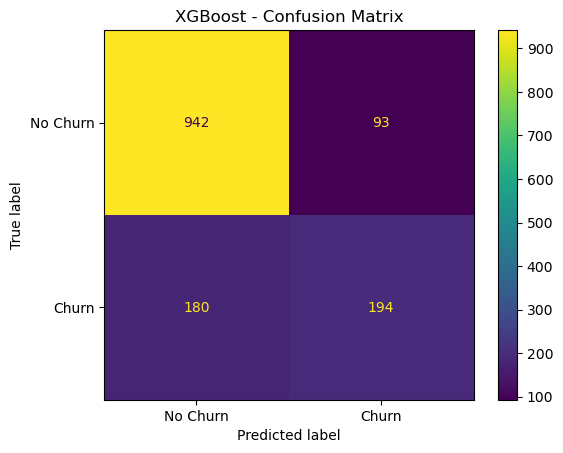

In [94]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

Using the default classification threshold, the XGBoost model produced:

- **942 True Negatives:** correctly identified non-churners.
- **194 True Positives:** correctly identified churners.
- **93 False Positives:** customers incorrectly flagged as churn risks.
- **180 False Negatives:** churners that the model failed to identify.

The model achieves a Precision of approximately **67.6%**, meaning that roughly two-thirds of customers flagged as churn risks actually churn.

However, Recall is approximately **51.9%**, meaning that the model currently identifies only about half of all actual churners.

This highlights an important business trade-off: lowering the classification threshold may identify more churners and reduce false negatives, but will also generate more false positives.

Threshold selection should therefore consider the relative business costs of missed churners and unnecessary retention interventions.

## 10. Classification Threshold Optimization

The classification model produces churn probabilities rather than only binary predictions.

By default, a threshold of 0.50 is commonly used to convert probabilities into predicted classes. However, this threshold may not be optimal for the business objective.

Lower thresholds tend to increase Recall and reduce False Negatives, while potentially decreasing Precision and increasing False Positives.

Different classification thresholds will therefore be evaluated before defining the final decision rule.

In [97]:
final_model = best_xgb
final_model.fit(X_train, y_train)
y_proba = final_model.predict_proba(X_test)[:, 1]
y_proba[:10]

array([0.03366297, 0.7652781 , 0.06335239, 0.32062525, 0.02361024,
       0.5824372 , 0.46112925, 0.10132457, 0.01276795, 0.35009506],
      dtype=float32)

In [98]:
threshold = 0.50

y_pred_threshold = (
    y_proba >= threshold
).astype(int)

In [99]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

In [100]:
threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.2,0.711852,0.476048,0.850267,0.610365
1,0.3,0.755855,0.527372,0.772727,0.626898
2,0.4,0.796309,0.604819,0.671123,0.636248
3,0.5,0.806246,0.675958,0.518717,0.586989
4,0.6,0.796309,0.735135,0.363636,0.486583
5,0.7,0.779986,0.796296,0.229947,0.356846


In [102]:
from sklearn.model_selection import cross_val_predict
y_train_proba = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [103]:
import numpy as np

thresholds = np.arange(
    0.10,
    0.81,
    0.01
)

In [105]:
threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_train_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_train,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_train,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_train,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_train,
            y_pred_threshold
        )
    })

    threshold_validation_df = pd.DataFrame(
    threshold_results
)

threshold_validation_df.head()

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.612531,0.401826,0.941806,0.563313
1,0.11,0.624956,0.409384,0.933779,0.569215
2,0.12,0.643415,0.421884,0.928428,0.580146
3,0.13,0.654952,0.429866,0.920401,0.586031
4,0.14,0.663827,0.436119,0.911037,0.589866


In [106]:
best_threshold_row = threshold_validation_df.loc[
    threshold_validation_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.330000
Accuracy     0.780795
Precision    0.567568
Recall       0.730435
F1           0.638783
Name: 23, dtype: float64

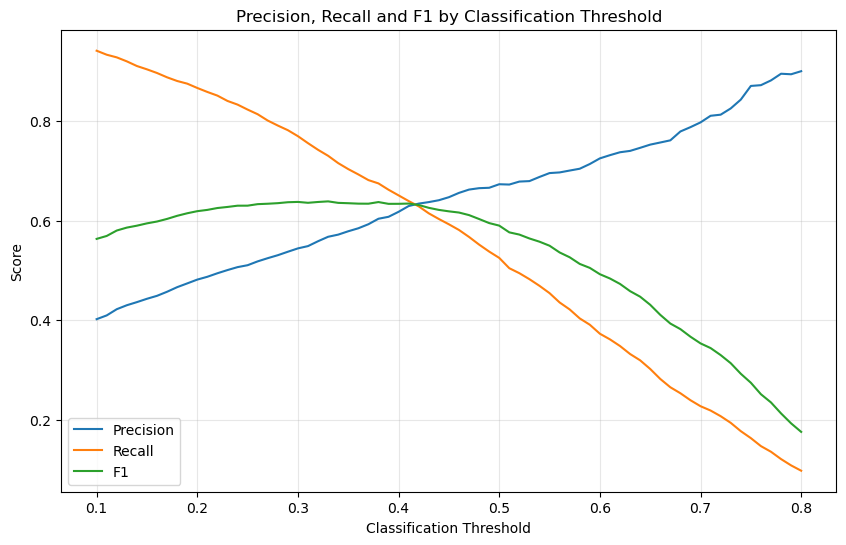

In [108]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_validation_df["Threshold"],
    threshold_validation_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_validation_df["Threshold"],
    threshold_validation_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_validation_df["Threshold"],
    threshold_validation_df["F1"],
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [109]:
best_threshold = best_threshold_row["Threshold"]

best_threshold

np.float64(0.32999999999999985)

In [110]:
best_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

In [112]:
y_test_pred_optimized = (
    y_test_proba >= best_threshold
).astype(int)

In [113]:
optimized_metrics = {
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred_optimized
    ),
    "Precision": precision_score(
        y_test,
        y_test_pred_optimized
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_optimized
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_optimized
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_proba
    )
}

optimized_metrics

{'Threshold': np.float64(0.32999999999999985),
 'Accuracy': 0.7743080198722498,
 'Precision': 0.5555555555555556,
 'Recall': 0.7486631016042781,
 'F1': 0.6378132118451025,
 'ROC-AUC': 0.848172259681211}

In [114]:
cm_optimized = confusion_matrix(
    y_test,
    y_test_pred_optimized
)

cm_optimized

array([[811, 224],
       [ 94, 280]])

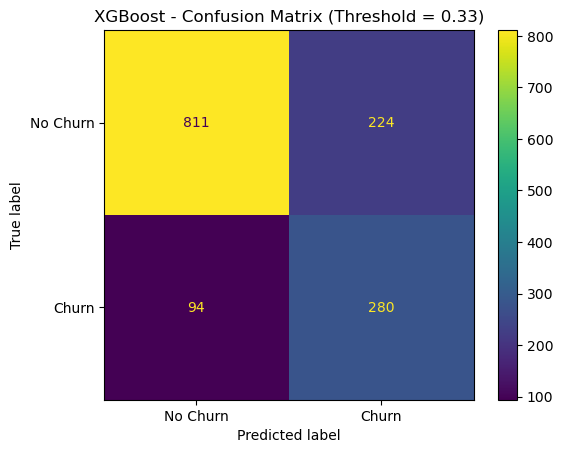

In [115]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title(
    f"XGBoost - Confusion Matrix (Threshold = {best_threshold:.2f})"
)

plt.show()

### Optimized Classification Threshold

The classification threshold was optimized using out-of-fold predictions from the training data, avoiding the use of the test set during threshold selection.

A threshold of **0.33** maximized the validation F1-score.

When applied to the untouched test set, the optimized threshold increased Recall from **51.9% to 74.9%** and F1-score from **58.7% to 63.8%**.

The number of correctly identified churners increased from **194 to 280**, while False Negatives decreased from **180 to 94**.

This improvement comes at the cost of additional False Positives, which increased from **93 to 224**, reducing Precision from **67.6% to 55.6%**.

The validation F1-score (0.639) and test F1-score (0.638) were nearly identical, indicating that the selected threshold generalized well to unseen data.

The optimal production threshold ultimately depends on the business costs associated with missed churners and unnecessary retention interventions.

In [116]:
feature_names = (
    best_xgb
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

len(feature_names)

46

In [117]:
feature_names[:20]

array(['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges',
       'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0',
       'cat__SeniorCitizen_1', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No'], dtype=object)

In [118]:
importances = (
    best_xgb
    .named_steps["model"]
    .feature_importances_
)

len(importances)

46

In [120]:
len(feature_names)
len(importances)

46

In [121]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(15)

,Feature,Importance
0,cat__Contract_Month-to-month,0.249986
1,cat__OnlineSecurity_No,0.091952
2,cat__InternetService_DSL,0.073362
3,cat__TechSupport_No,0.051648
4,cat__InternetService_Fiber optic,0.049993
5,cat__Contract_Two year,0.042218
6,cat__PaymentMethod_Electronic check,0.031100
7,num__tenure,0.030426
8,cat__OnlineBackup_No internet service,0.023522
9,cat__InternetService_No,0.021367


In [122]:
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [123]:
feature_importance_df.head(15)

,Feature,Importance
0,Contract_Month-to-month,0.249986
1,OnlineSecurity_No,0.091952
2,InternetService_DSL,0.073362
3,TechSupport_No,0.051648
4,InternetService_Fiber optic,0.049993
5,Contract_Two year,0.042218
6,PaymentMethod_Electronic check,0.031100
7,tenure,0.030426
8,OnlineBackup_No internet service,0.023522
9,InternetService_No,0.021367


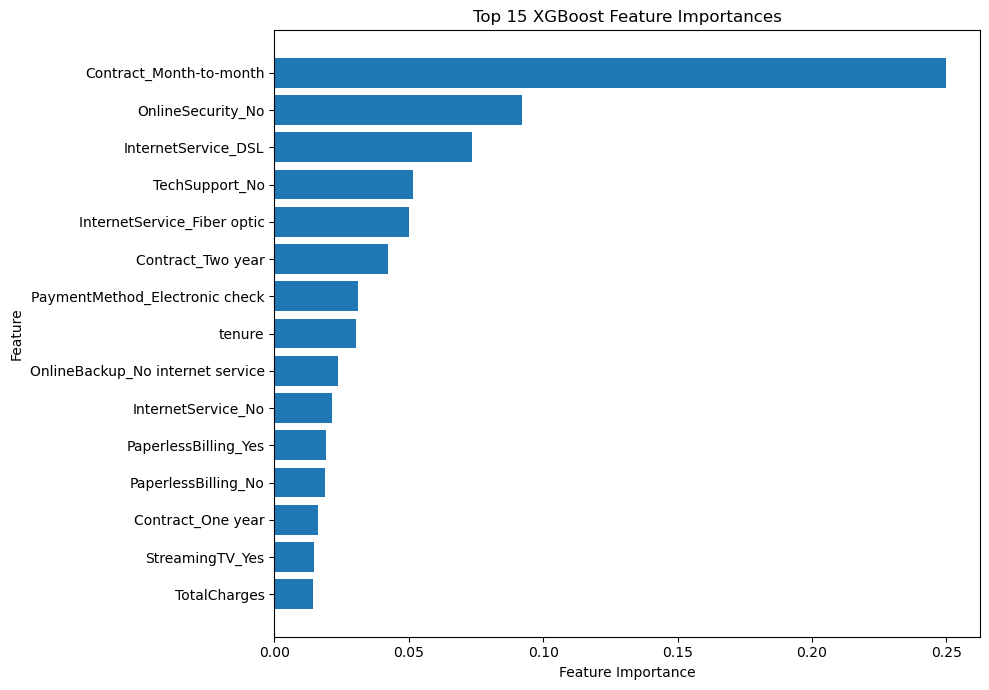

In [124]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [127]:
!pip install shap
import shap

print(shap.__version__)


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

0.52.0


In [129]:
X_test_transformed = (
    best_xgb
    .named_steps["preprocessor"]
    .transform(X_test)
)

X_test_transformed.shape

(1409, 46)

In [131]:
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_shap.head()


,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__SeniorCitizen_0,cat__SeniorCitizen_1,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,1.608483,1.629976,2.706828,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2280,-0.996684,1.168725,-0.610260,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2235,0.346606,0.445324,0.400116,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4460,-0.589626,0.440347,-0.364451,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3761,1.608483,0.588013,1.588421,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [132]:
xgb_model = best_xgb.named_steps["model"]

In [135]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_shap)
shap_values.shape

(1409, 46)

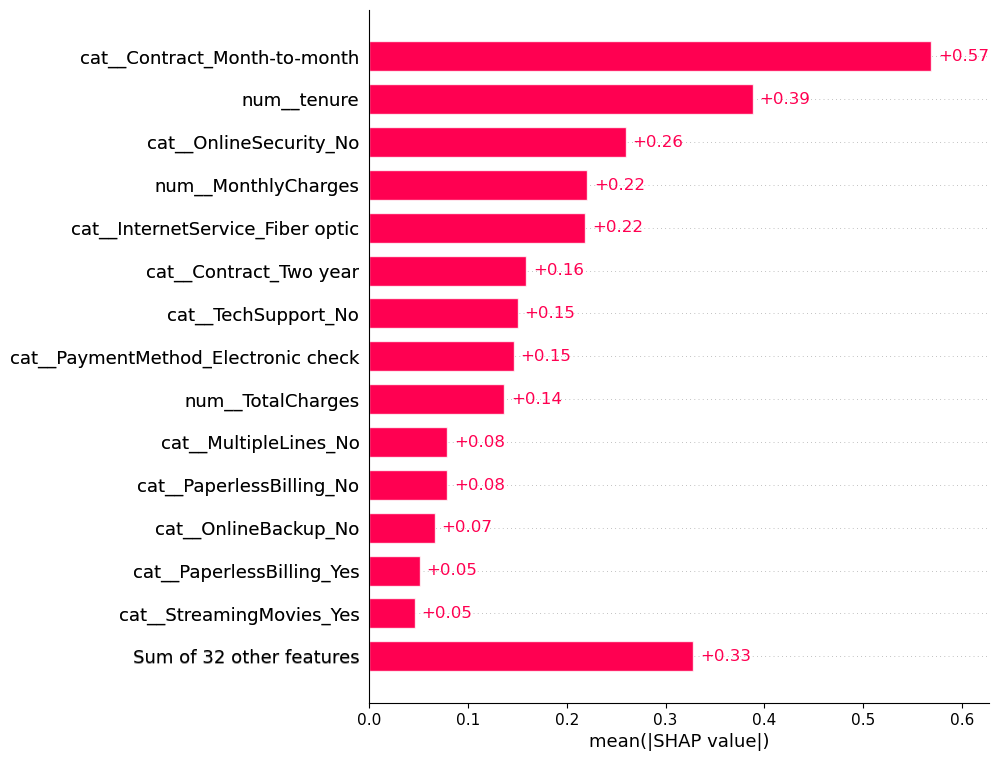

In [136]:
shap.plots.bar(
    shap_values,
    max_display=15
)

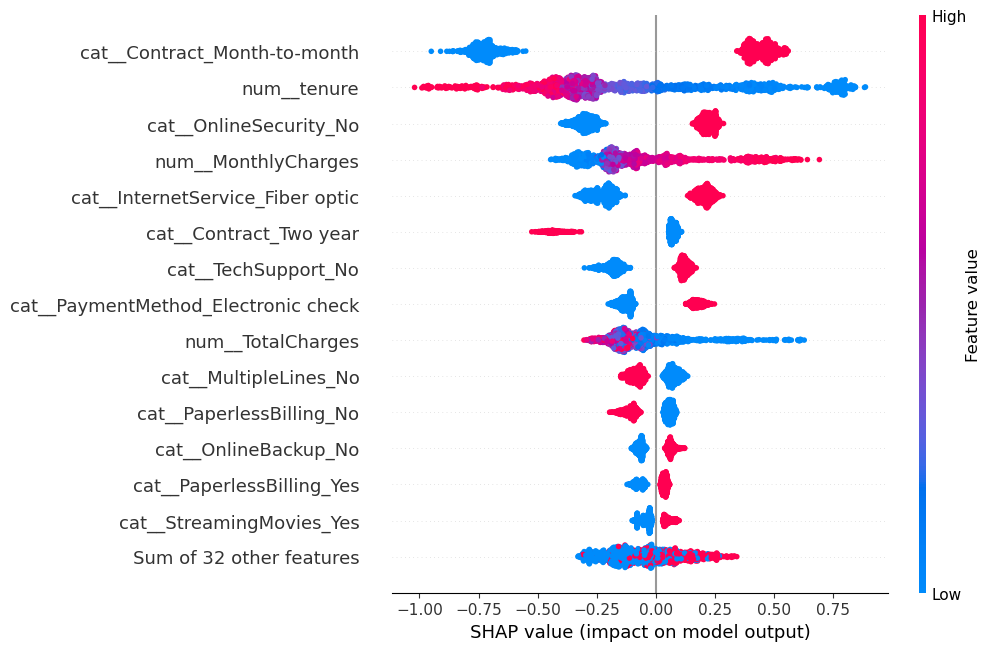

In [138]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [140]:
highest_risk_position = y_test_proba.argmax()

highest_risk_position

np.int64(1090)

In [141]:
highest_risk_probability = y_test_proba[
    highest_risk_position
]

highest_risk_probability

np.float32(0.9130543)

In [142]:
X_test.iloc[
    highest_risk_position
]

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object

In [143]:
y_test.iloc[
    highest_risk_position
]

np.int64(1)

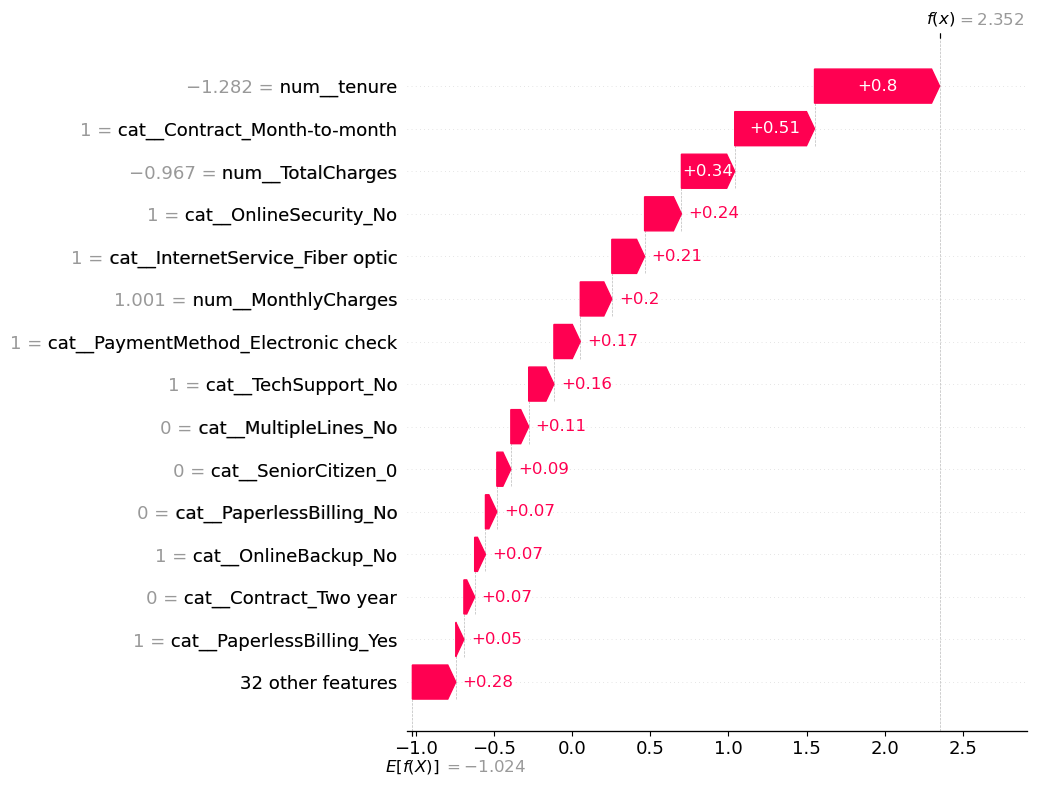

In [148]:
shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=15
)

### Individual Prediction Explanation

The customer with the highest predicted churn risk received a churn probability of approximately **91.3%** and actually churned, representing a True Positive prediction.

SHAP analysis shows that the prediction was primarily driven by very low tenure, a month-to-month contract, low accumulated TotalCharges, absence of Online Security, Fiber Optic internet service, and relatively high MonthlyCharges.

The strongest individual factor was the customer's very low tenure (1 month), followed by the month-to-month contract.

The SHAP waterfall explains the prediction in the model's raw output (log-odds) space. The final model output of approximately 2.35 corresponds to a churn probability of approximately 91.3%.

These results explain the model's prediction but should not be interpreted as evidence that these characteristics causally produce churn.

In [149]:
import joblib
import os

In [151]:
os.makedirs("models", exist_ok=True)

In [152]:
joblib.dump(
    best_xgb,
    "models/churn_model.joblib"
)

['models/churn_model.joblib']

In [153]:
joblib.dump(
    float(best_threshold),
    "models/churn_threshold.joblib"
)

['models/churn_threshold.joblib']

In [154]:
loaded_model = joblib.load(
    "models/churn_model.joblib"
)

loaded_threshold = joblib.load(
    "models/churn_threshold.joblib"
)

In [155]:
loaded_threshold

0.32999999999999985

In [156]:
new_customer = X_test.iloc[[0]]

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


In [157]:
churn_probability = loaded_model.predict_proba(
    new_customer
)[:, 1][0]

churn_probability

np.float32(0.033662975)

In [158]:
prediction = int(
    churn_probability >= loaded_threshold
)

prediction

0

In [159]:
prediction_label = (
    "Churn"
    if prediction == 1
    else "No Churn"
)

print(f"Churn probability: {churn_probability:.2%}")
print(f"Threshold: {loaded_threshold:.2f}")
print(f"Prediction: {prediction_label}")

Churn probability: 3.37%
Threshold: 0.33
Prediction: No Churn


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.predict import predict_churn

In [2]:
customer = {
    "gender": "Male",
    "SeniorCitizen": 1,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.10,
    "TotalCharges": 95.10
}

result = predict_churn(customer)

result

{'churn_probability': 0.9130542874336243,
 'threshold': 0.32999999999999985,
 'prediction': 1,
 'prediction_label': 'Churn'}

# Lesson 9 — MLflow

MLflow will be used to track and compare Machine Learning experiments by recording models, hyperparameters, metrics, and artifacts.

In [3]:
import mlflow

print("MLflow:", mlflow.__version__)

MLflow: 3.15.1


In [4]:
mlflow.set_experiment("customer-churn")

2026/08/16 17:21:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/16 17:21:34 INFO mlflow.store.db.utils: Updating database tables
2026/08/16 17:21:38 INFO mlflow.tracking.fluent: Experiment with name 'customer-churn' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/felip/OneDrive/Documentos/GitHub/customer-churn-ml/mlruns/1', creation_time=1786911698499, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786911698499, lifecycle_stage='active', name='customer-churn', tags={}, trace_location=None, workspace='default'>

In [5]:
experiment = mlflow.get_experiment_by_name("customer-churn")

print("Experiment ID:", experiment.experiment_id)
print("Experiment Name:", experiment.name)

Experiment ID: 1
Experiment Name: customer-churn


In [6]:
with mlflow.start_run(run_name="xgboost_final"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("threshold", 0.33)

    mlflow.log_metric("accuracy", 0.806246)
    mlflow.log_metric("precision", 0.675958)
    mlflow.log_metric("recall", 0.518717)
    mlflow.log_metric("f1", 0.586989)
    mlflow.log_metric("roc_auc", 0.848172)

In [7]:
with mlflow.start_run(run_name="xgboost_production"):

    # Model information
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("threshold", 0.33)
    mlflow.log_param("optimization_metric", "ROC-AUC")
    mlflow.log_param("tuning_method", "RandomizedSearchCV")

    # Metrics with optimized threshold
    mlflow.log_metric("accuracy", 0.774308)
    mlflow.log_metric("precision", 0.555556)
    mlflow.log_metric("recall", 0.748663)
    mlflow.log_metric("f1", 0.637813)
    mlflow.log_metric("roc_auc", 0.848172)

In [13]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"

for file in MODELS_DIR.iterdir():
    print(file.name)

churn_model.joblib
churn_threshold.joblib


In [14]:
import joblib

loaded_model = joblib.load(
    MODELS_DIR / "churn_model.joblib"
)

loaded_threshold = joblib.load(
    MODELS_DIR / "churn_threshold.joblib"
)

print("Model loaded successfully.")
print("Threshold:", loaded_threshold)

Model loaded successfully.
Threshold: 0.32999999999999985


In [15]:
loaded_model.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.6,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.03,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': 5,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 200,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.6,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [16]:
xgb_model = loaded_model.named_steps["model"]

important_params = {
    "model": "XGBoost",
    "tuning_method": "RandomizedSearchCV",
    "optimization_metric": "ROC-AUC",
    "threshold": float(loaded_threshold),
    "n_estimators": xgb_model.n_estimators,
    "learning_rate": xgb_model.learning_rate,
    "max_depth": xgb_model.max_depth,
    "min_child_weight": xgb_model.min_child_weight,
    "subsample": xgb_model.subsample,
    "colsample_bytree": xgb_model.colsample_bytree,
    "objective": xgb_model.objective,
    "eval_metric": xgb_model.eval_metric,
    "random_state": xgb_model.random_state
}

important_params

{'model': 'XGBoost',
 'tuning_method': 'RandomizedSearchCV',
 'optimization_metric': 'ROC-AUC',
 'threshold': 0.32999999999999985,
 'n_estimators': 200,
 'learning_rate': 0.03,
 'max_depth': 3,
 'min_child_weight': 5,
 'subsample': 0.6,
 'colsample_bytree': 0.6,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'random_state': 42}

In [17]:
import mlflow

mlflow.set_experiment("customer-churn")

with mlflow.start_run(run_name="xgboost_production_final"):

    # Log hyperparameters
    mlflow.log_params(important_params)

    # Log final metrics with optimized threshold
    mlflow.log_metric("accuracy", 0.774308)
    mlflow.log_metric("precision", 0.555556)
    mlflow.log_metric("recall", 0.748663)
    mlflow.log_metric("f1", 0.637813)
    mlflow.log_metric("roc_auc", 0.848172)

    # Log production artifacts
    mlflow.log_artifact(
        str(PROJECT_ROOT / "models" / "churn_model.joblib"),
        artifact_path="model"
    )

    mlflow.log_artifact(
        str(PROJECT_ROOT / "models" / "churn_threshold.joblib"),
        artifact_path="model"
    )

print("Production run logged successfully.")

Production run logged successfully.
